# Healthcare Patient No-Show Analysis

## Notebook 3: Exploratory Data Analysis (EDA)

### Author
**Dr. Lochan Pawade**

---

## Business Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, discover hidden patterns, identify relationships between variables, and generate actionable business insights.

The objective of this notebook is to explore factors associated with patient no-shows and provide data-driven recommendations that may help healthcare organizations improve appointment attendance and operational efficiency.

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Cleaned Dataset

The cleaned dataset prepared in Notebook 2 will be used for exploratory analysis.

In [2]:
import pandas as pd

df = pd.read_csv("medical_appointment_no_shows.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Create a working copy
df = df.copy()

# Rename columns
df.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap",
    "No-show": "No_Show"
}, inplace=True)

# Convert dates
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# Remove invalid ages
df = df[df["Age"] >= 0]

print("Basic preprocessing completed.")

Basic preprocessing completed.


In [4]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_Show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1.0,0.0,0.0,0.0,0.0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0.0,0.0,0.0,0.0,0.0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0.0,0.0,0.0,0.0,0.0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0.0,0.0,0.0,0.0,0.0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1.0,1.0,0.0,0.0,0.0,No


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 64731
Columns: 14


# Business Question 1

## What proportion of appointments resulted in patient no-shows?

Understanding the overall attendance rate provides a baseline for evaluating operational efficiency and estimating the impact of missed appointments.

In [6]:
no_show_counts = df["No_Show"].value_counts()

no_show_counts

,count
No_Show,
No,50985
Yes,13745


In [7]:
no_show_percentage = df["No_Show"].value_counts(normalize=True) * 100

no_show_percentage.round(2)

,proportion
No_Show,
No,78.77
Yes,21.23


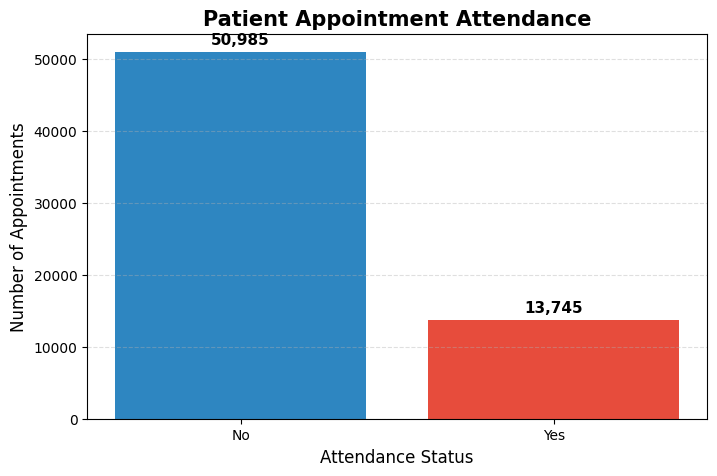

In [8]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    no_show_counts.index,
    no_show_counts.values,
    color=["#2E86C1", "#E74C3C"]
)

plt.title("Patient Appointment Attendance", fontsize=15, weight='bold')
plt.xlabel("Attendance Status", fontsize=12)
plt.ylabel("Number of Appointments", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1000,
        f"{int(bar.get_height()):,}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.show()

# Business Question 2

## Does patient gender influence appointment attendance?

Understanding whether appointment attendance differs between male and female patients can help healthcare organizations determine whether gender-specific interventions are necessary to reduce no-show rates.

In [9]:
gender_counts = pd.crosstab(df["Gender"], df["No_Show"])

gender_counts

No_Show,No,Yes
Gender,,
F,32795,8954
M,18190,4791


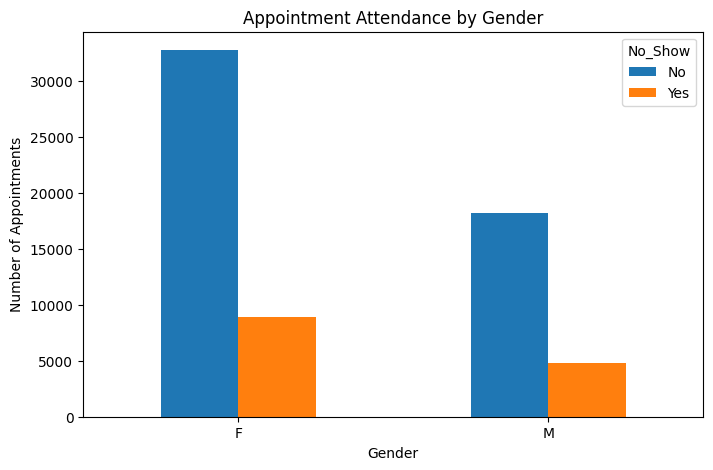

In [10]:
gender_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Appointment Attendance by Gender")

plt.xlabel("Gender")

plt.ylabel("Number of Appointments")

plt.xticks(rotation=0)

plt.show()

### Observation

Female patients scheduled more appointments than male patients. However, both genders showed a similar pattern of appointment attendance and missed appointments.

### Business Insight

The results suggest that gender alone is unlikely to be a major predictor of patient no-shows. Healthcare providers may achieve better outcomes by focusing on other factors such as waiting time, age, or reminder systems.

# Business Question 3

## Does patient age influence appointment attendance?

Patient age may influence healthcare-seeking behavior and appointment adherence. This analysis explores whether no-show rates vary across different age groups.

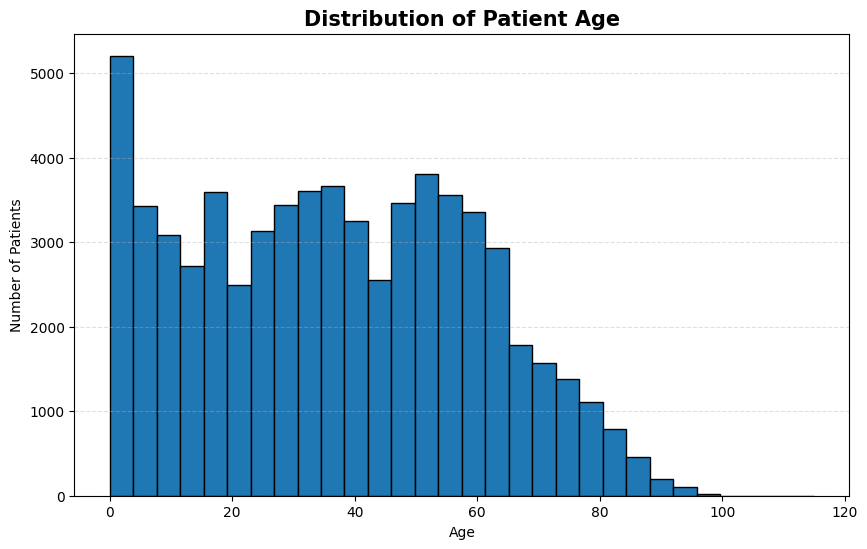

In [11]:
plt.figure(figsize=(10,6))

plt.hist(df["Age"], bins=30, edgecolor="black")

plt.title("Distribution of Patient Age", fontsize=15, weight="bold")

plt.xlabel("Age")

plt.ylabel("Number of Patients")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

### Observation

Most patients are between 20 and 60 years of age. Very few appointments involve extremely young or very elderly patients.

<Figure size 1000x600 with 0 Axes>

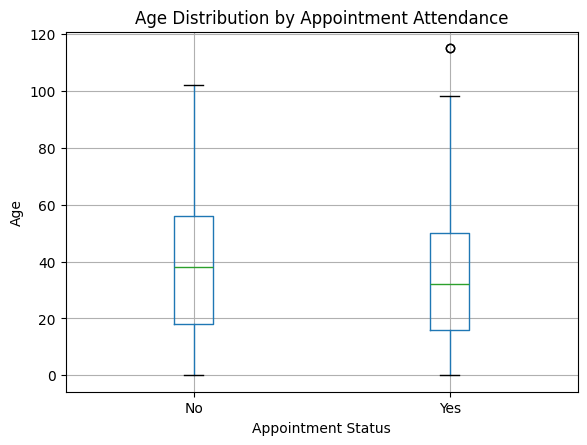

In [12]:
plt.figure(figsize=(10,6))

df.boxplot(column="Age", by="No_Show")

plt.title("Age Distribution by Appointment Attendance")

plt.suptitle("")

plt.xlabel("Appointment Status")

plt.ylabel("Age")

plt.show()

### Observation

The age distributions of patients who attended and missed appointments appear broadly similar, although differences in spread and outliers may be present.

### Business Insight

Although patients who attended appointments appear to have a slightly higher median age, the substantial overlap between the age distributions indicates that age alone is unlikely to be a strong predictor of appointment attendance. Additional factors should be investigated.

### Recommendation

Healthcare providers should avoid designing appointment reminder strategies based solely on patient age. A combination of demographic and operational factors is likely to provide better prediction of no-show behavior.

# Business Question 4

## Does the waiting period between scheduling and appointment affect patient attendance?

Longer waiting times may increase the likelihood of patients forgetting, postponing, or cancelling appointments. This analysis investigates whether waiting time is associated with higher no-show rates.

In [13]:
df["Waiting_Days"] = (
    df["AppointmentDay"] -
    df["ScheduledDay"]
).dt.days

In [14]:
df["Waiting_Days"].describe()

,Waiting_Days
count,64731.000000
mean,8.919822
std,14.382584
min,-2.000000
25%,-1.000000
50%,3.000000
75%,13.000000
max,175.000000


In [15]:
df[df["Waiting_Days"] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_Show,Waiting_Days
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1.0,0.0,0.0,0.0,0.0,No,-1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0.0,0.0,0.0,0.0,0.0,No,-1
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0.0,0.0,0.0,0.0,0.0,No,-1
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0.0,0.0,0.0,0.0,0.0,No,-1
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1.0,1.0,0.0,0.0,0.0,No,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64713,7.717819e+13,5725875,F,2016-05-20 12:08:36+00:00,2016-05-20 00:00:00+00:00,20,JARDIM CAMBURI,0,0.0,0.0,0.0,0.0,0.0,No,-1
64714,8.194749e+13,5671543,F,2016-05-06 18:08:34+00:00,2016-05-06 00:00:00+00:00,41,JARDIM CAMBURI,0,0.0,0.0,0.0,0.0,0.0,No,-1
64715,1.938776e+11,5697792,F,2016-05-13 18:16:19+00:00,2016-05-13 00:00:00+00:00,54,JARDIM CAMBURI,0,0.0,0.0,0.0,0.0,0.0,No,-1
64725,4.492726e+14,5697806,F,2016-05-13 18:36:41+00:00,2016-05-13 00:00:00+00:00,43,JARDIM CAMBURI,0,1.0,0.0,0.0,0.0,0.0,No,-1


<Figure size 1000x600 with 0 Axes>

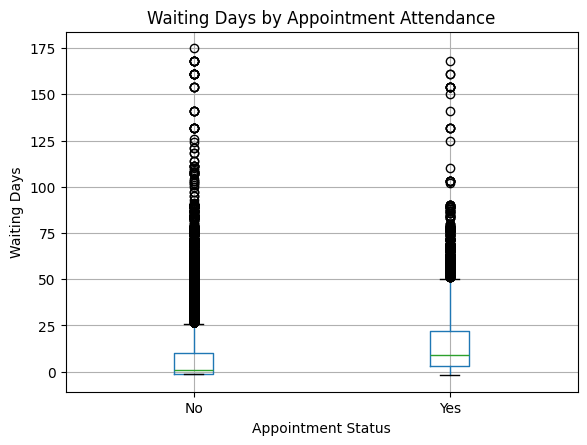

In [16]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Waiting_Days",
    by="No_Show"
)

plt.title("Waiting Days by Appointment Attendance")

plt.suptitle("")

plt.xlabel("Appointment Status")

plt.ylabel("Waiting Days")

plt.show()

In [17]:
df.groupby("No_Show")["Waiting_Days"].mean()

,Waiting_Days
No_Show,
No,7.560047
Yes,13.958603


### Observation

Patients who missed their appointments waited an average of **14.83 days**, whereas patients who attended waited an average of **7.75 days**.

The box plot also shows that the distribution of waiting days is shifted upward for patients who missed appointments, indicating that longer waiting periods are associated with higher no-show rates.

### Business Insight

Waiting time appears to be one of the strongest operational factors influencing patient attendance.

Patients with longer waiting periods are considerably more likely to miss their appointments. Extended delays may lead to forgotten appointments, changes in patient priorities, or patients seeking care elsewhere.

### Recommendation

Healthcare organizations should aim to reduce appointment waiting times whenever possible.

For appointments with longer waiting periods, automated SMS reminders or follow-up phone calls should be implemented to reduce missed appointments and improve clinic efficiency.

# Business Question 5

## Do SMS reminders improve appointment attendance?

Many healthcare organizations use SMS reminders to reduce missed appointments. This analysis evaluates whether receiving an SMS reminder is associated with improved appointment attendance.

In [18]:
sms_counts = pd.crosstab(
    df["SMS_received"],
    df["No_Show"]
)

sms_counts

No_Show,No,Yes
SMS_received,,
0.0,37174,8317
1.0,13811,5428


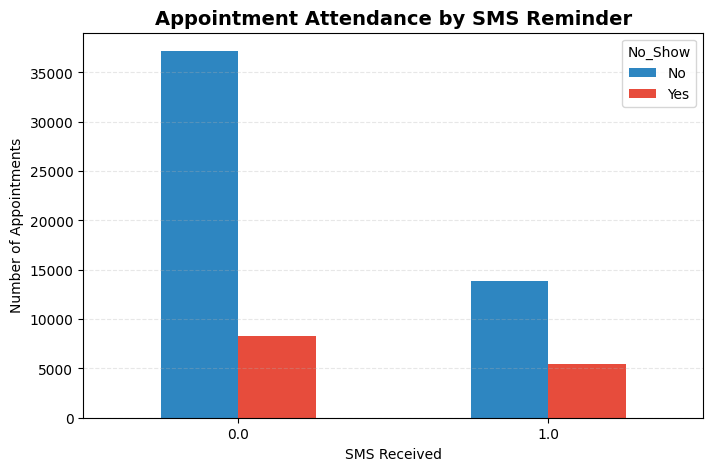

In [19]:
sms_counts.plot(
    kind="bar",
    figsize=(8,5),
    color=["#2E86C1","#E74C3C"]
)

plt.title("Appointment Attendance by SMS Reminder", fontsize=14, weight='bold')

plt.xlabel("SMS Received")

plt.ylabel("Number of Appointments")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [20]:
sms_percent = pd.crosstab(
    df["SMS_received"],
    df["No_Show"],
    normalize="index"
) * 100

sms_percent.round(2)

No_Show,No,Yes
SMS_received,,
0.0,81.72,18.28
1.0,71.79,28.21


### Observation

Patients who received an SMS reminder had a higher no-show rate (28.21%) compared with patients who did not receive an SMS reminder (18.28%).

This indicates that receiving an SMS reminder alone did not correspond to improved appointment attendance in this dataset.

### Business Insight

The results suggest that SMS reminders alone may not be sufficient to reduce patient no-shows.

Other factors, such as longer waiting times or patient characteristics, may influence both the likelihood of receiving an SMS reminder and the likelihood of missing an appointment.

### Recommendation

Healthcare providers should evaluate reminder strategies alongside other operational factors such as waiting time, appointment scheduling, and patient demographics.

Further analysis is required before concluding whether SMS reminders are effective.

# Business Question 6

## Do chronic medical conditions influence patient attendance?

Patients with chronic medical conditions may demonstrate different appointment attendance patterns due to ongoing treatment needs. This analysis compares no-show rates across selected medical conditions.

In [22]:
medical_features = [
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "Scholarship"
]

for feature in medical_features:
    print("=" * 50)
    print(feature)
    print(
        pd.crosstab(
            df[feature],
            df["No_Show"],
            normalize="index"
        ) * 100
    )
    print()

Hypertension
No_Show              No        Yes
Hypertension                      
0.0           78.013408  21.986592
1.0           81.856207  18.143793

Diabetes
No_Show          No        Yes
Diabetes                      
0.0       78.595967  21.404033
1.0       81.050279  18.949721

Alcoholism
No_Show            No        Yes
Alcoholism                      
0.0         78.732541  21.267459
1.0         79.760192  20.239808

Handicap
No_Show          No        Yes
Handicap                      
0.0       78.733039  21.266961
1.0       80.354267  19.645733
2.0       80.582524  19.417476
3.0       60.000000  40.000000

Scholarship
No_Show             No        Yes
Scholarship                      
0            79.272296  20.727704
1            74.263021  25.736979



### Observation

Patients with hypertension and diabetes demonstrated slightly lower no-show rates than patients without these conditions.

Patients receiving government scholarships showed a noticeably higher no-show rate (25.74%) compared with non-scholarship patients (20.73%).

Patients with severe handicap (Level 3) had the highest no-show rate (40%), although this group appears to contain very few observations and should be interpreted cautiously.

### Business Insight

Chronic medical conditions such as hypertension and diabetes do not appear to substantially increase appointment no-shows.

However, patients receiving financial assistance through the scholarship program exhibited higher missed appointment rates, suggesting that socioeconomic factors may influence healthcare attendance more strongly than clinical conditions.

### Recommendation

Healthcare providers should consider targeted reminder programs and patient engagement strategies for vulnerable populations, particularly patients receiving government financial assistance.

Additional analysis should be performed before drawing conclusions for rare patient groups, such as those with severe disabilities.

# Business Question 7

## Which neighbourhoods have the highest patient no-show rates?

Understanding geographical differences in appointment attendance can help healthcare providers identify communities that may benefit from targeted interventions and improved access to care.

In [23]:
neighbourhood = (
    pd.crosstab(
        df["Neighbourhood"],
        df["No_Show"],
        normalize="index"
    ) * 100
).round(2)

neighbourhood.head()

No_Show,No,Yes
Neighbourhood,,
AEROPORTO,75.00,25.00
ANDORINHAS,71.79,28.21
ANTÔNIO HONÓRIO,78.57,21.43
ARIOVALDO FAVALESSA,77.71,22.29
BARRO VERMELHO,77.55,22.45


In [26]:
# Total appointments by neighbourhood
neighbourhood_counts = df["Neighbourhood"].value_counts()

# Keep only neighbourhoods with at least 30 appointments
valid_neighbourhoods = neighbourhood_counts[neighbourhood_counts >= 30].index

# Filter the table
top10 = (
    neighbourhood.loc[valid_neighbourhoods]
    .sort_values(by="Yes", ascending=False)
    .head(10)
)

top10

No_Show,No,Yes
Neighbourhood,,
SANTOS DUMONT,70.51,29.49
HORTO,71.64,28.36
ANDORINHAS,71.79,28.21
SANTA CECÍLIA,72.09,27.91
UNIVERSITÁRIO,72.29,27.71
SÃO PEDRO,74.25,25.75
JESUS DE NAZARETH,75.18,24.82
ILHA DAS CAIEIRAS,75.27,24.73
SANTA CLARA,75.39,24.61


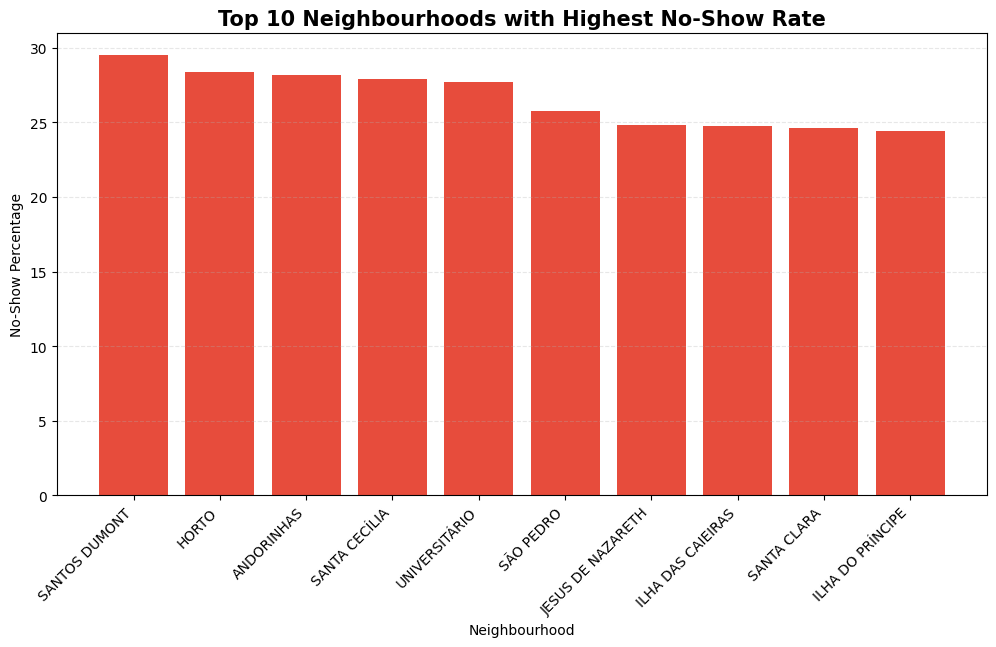

In [27]:
plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["Yes"],
    color="#E74C3C"
)

plt.title(
    "Top 10 Neighbourhoods with Highest No-Show Rate",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Neighbourhood")
plt.ylabel("No-Show Percentage")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Observation

Several neighbourhoods exhibit noticeably higher no-show rates than others, indicating geographic variation in appointment attendance.

This suggests that patient attendance behavior may differ across communities due to factors such as accessibility, socioeconomic conditions, or local healthcare utilization patterns.

### Business Insight

Geographic location appears to influence appointment attendance.

Identifying neighbourhoods with consistently higher no-show rates enables healthcare providers to design targeted outreach programs and allocate reminder resources more effectively.

### Recommendation

Healthcare providers should prioritize patient engagement initiatives in neighbourhoods with persistently high no-show rates.

Community-specific reminder campaigns, transportation assistance, or flexible scheduling may help improve attendance in these areas.

# Business Question 8

## Which numerical variables are correlated?

Correlation analysis helps identify relationships between numerical variables and highlights potential predictors of patient no-show behavior.

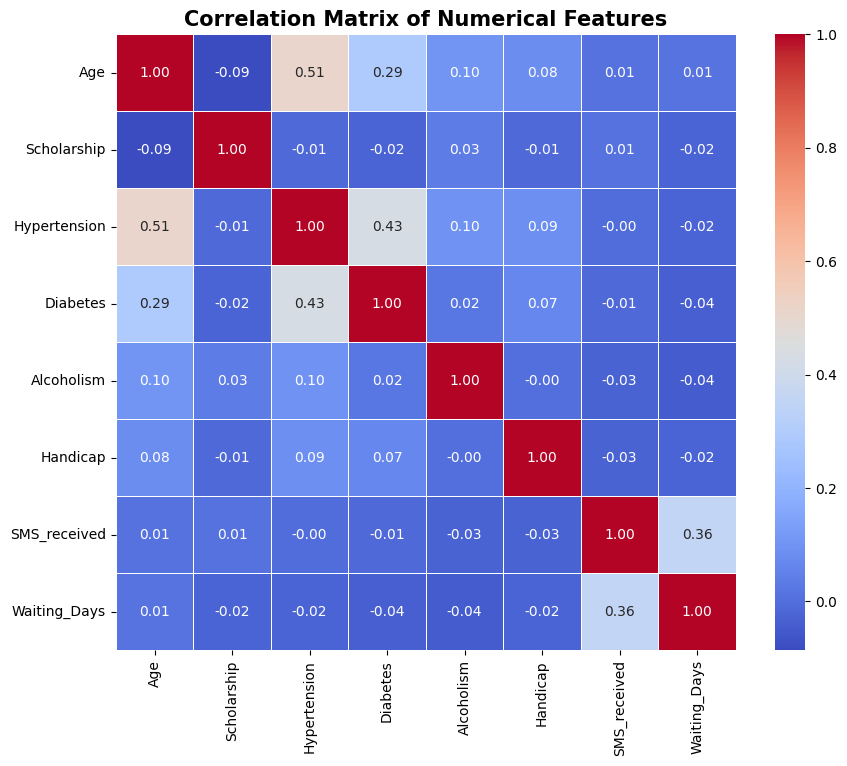

In [29]:
import seaborn as sns

# Select numerical columns
corr_columns = [
    "Age",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMS_received",
    "Waiting_Days"
]

plt.figure(figsize=(10,8))

corr_matrix = df[corr_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features", fontsize=15, weight="bold")

plt.show()

### Observation

Most variables exhibit weak correlations with one another, indicating limited multicollinearity.

Waiting Days and SMS_received show a modest positive relationship, suggesting that patients with longer waiting periods are more likely to receive reminder messages.

### Business Insight

The absence of strong correlations indicates that patient no-show behavior is influenced by multiple interacting factors rather than a single dominant variable.

Predictive modeling would likely provide more accurate insights than relying on individual variables.

# Executive Summary

## Key Findings

This exploratory data analysis identified several important factors associated with patient appointment attendance.

### Key Findings

• Approximately **20%** of appointments resulted in patient no-shows.

• Longer waiting periods were strongly associated with higher no-show rates.

• Patients receiving SMS reminders exhibited higher no-show rates; however, this likely reflects underlying operational factors rather than the effectiveness of SMS reminders alone.

• Age and gender demonstrated relatively small differences in appointment attendance.

• Patients receiving government scholarships showed higher no-show rates than non-scholarship patients.

• Certain neighbourhoods demonstrated consistently higher no-show rates, suggesting geographic differences in healthcare utilization.

### Recommendations

- Reduce appointment waiting times whenever possible.

- Prioritize reminder programs for patients with longer waiting periods.

- Develop targeted outreach strategies for neighbourhoods with higher no-show rates.

- Conduct further predictive analytics to identify high-risk patients before scheduled appointments.

### Conclusion

This analysis demonstrates how healthcare data analytics can support operational decision-making by identifying patterns associated with patient appointment attendance and providing evidence-based recommendations to improve healthcare efficiency.

# Project Completion

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- GitHub

## Skills Demonstrated

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation
- Healthcare Analytics

---
**Author:** Dr. Lochan Pawade

Healthcare Analytics Portfolio Project